# <span style="color: purple;">Lesson 11 - Feature Engineering</span>

**Developers:** Brian  |  **Reviewers:** 

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Learned how crafting and transforming features can massively improve model performance.
- Constructed a new feature by combining existing ones.
- Transformed a skewed feature to help the model learn more easily.
- Standardized variables to put them on a "Level Playing Field".

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [1]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Fetch the Titanic dataset and clean missing numbers under the hood
titanic_data = fetch_openml('titanic', version=1, as_frame=True, parser='auto', data_home='./openml')
df = titanic_data.frame[['survived', 'age', 'sibsp', 'parch', 'fare']].copy()
df = df.dropna() # keep it simple, drop missing rows
df['survived'] = df['survived'].astype(int).map({0: 'No', 1: 'Yes'})

# Rename to be very clear
df = df.rename(columns={
    'survived': 'Survived',
    'age': 'Age',
    'sibsp': 'Siblings_Spouses',
    'parch': 'Parents_Children',
    'fare': 'Fare'
})

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🧩 What is Feature Engineering?</span>

Before deep learning and massive neural networks became popular, machine learning models were relatively simple algorithms. Because these early models couldn't automatically figure out complex, hidden relationships in the data on their own, human experts had to mathematically craft the perfect input variables for them. 

Historically, this process of solving inference problems by carefully crafting data was the absolute secret to winning early machine learning competitions. Data scientists would spend 90% of their time just manipulating columns of data before a model even saw it!

Even today, for many tabular (spreadsheet) datasets, giving a model "better" and more explicit information is often far more effective—and much faster—than just building a bigger, more complicated AI brain. A model is truly only as good as the data it is trained on.

<div class="alert alert-success">

**Feature Engineering** - Creating new features or transforming existing ones to explicitly give a model "better" information.

</div>

### The Three Main Techniques
Sometimes, the raw data we are given holds the truth, but it's hidden in disconnected pieces. 

1. **Feature Construction**: Combining two or more related variables into a single, more meaningful one.
2. **Feature Transformation**: Applying a mathematical function (like logarithm) to a variable to change its shape or squash extreme outliers.
3. **Standardization (Scaling)**: Adjusting the scale of all numeric variables so they share the exact same range, creating a "Level Playing Field" for the model.

Let's try this on the famous **Titanic dataset**!

---

## <span style="color: purple;">Step 1 - The Titanic Dataset & Exploration</span>

We will be working with the legendary **Titanic Dataset**. In 1912, the "unsinkable" Titanic sank in the icy waters of the North Atlantic after colliding with an iceberg. Amidst the chaos, some groups of people were statistically far more likely to make it onto a lifeboat than others. 

Can an AI learn the hidden patterns of survival? Let's break down our data:

- **The Data Points:** We have records for roughly **1,000 real passengers** onboard.
- **The Problem Type:** We are sorting people into two distinct groups (Survived or Died), making this a classic **Classification** problem!
- **The Target:** The exact column our AI is trying to predict correctly is `Survived` (where `No = Sadly Died`, and `Yes = Survived!`).
- **The 4 Starting Features:** We are giving our AI four simple clues to learn from:
  - `Age` (How old the passenger was)
  - `Siblings_Spouses` (How many siblings or spouses they brought along)
  - `Parents_Children` (How many parents or children they brought along)
  - `Fare` (How much they paid for their ticket to board the ship)

<div class="alert alert-info">

**Run the next cell** to look at the raw passenger data and generate some plots to see who survived!

</div>

,Survived,Age,Siblings_Spouses,Parents_Children,Fare
0,Yes,29.0000,0,0,211.3375
1,Yes,0.9167,1,2,151.5500
2,No,2.0000,1,2,151.5500
3,No,30.0000,1,2,151.5500
4,No,25.0000,1,2,151.5500


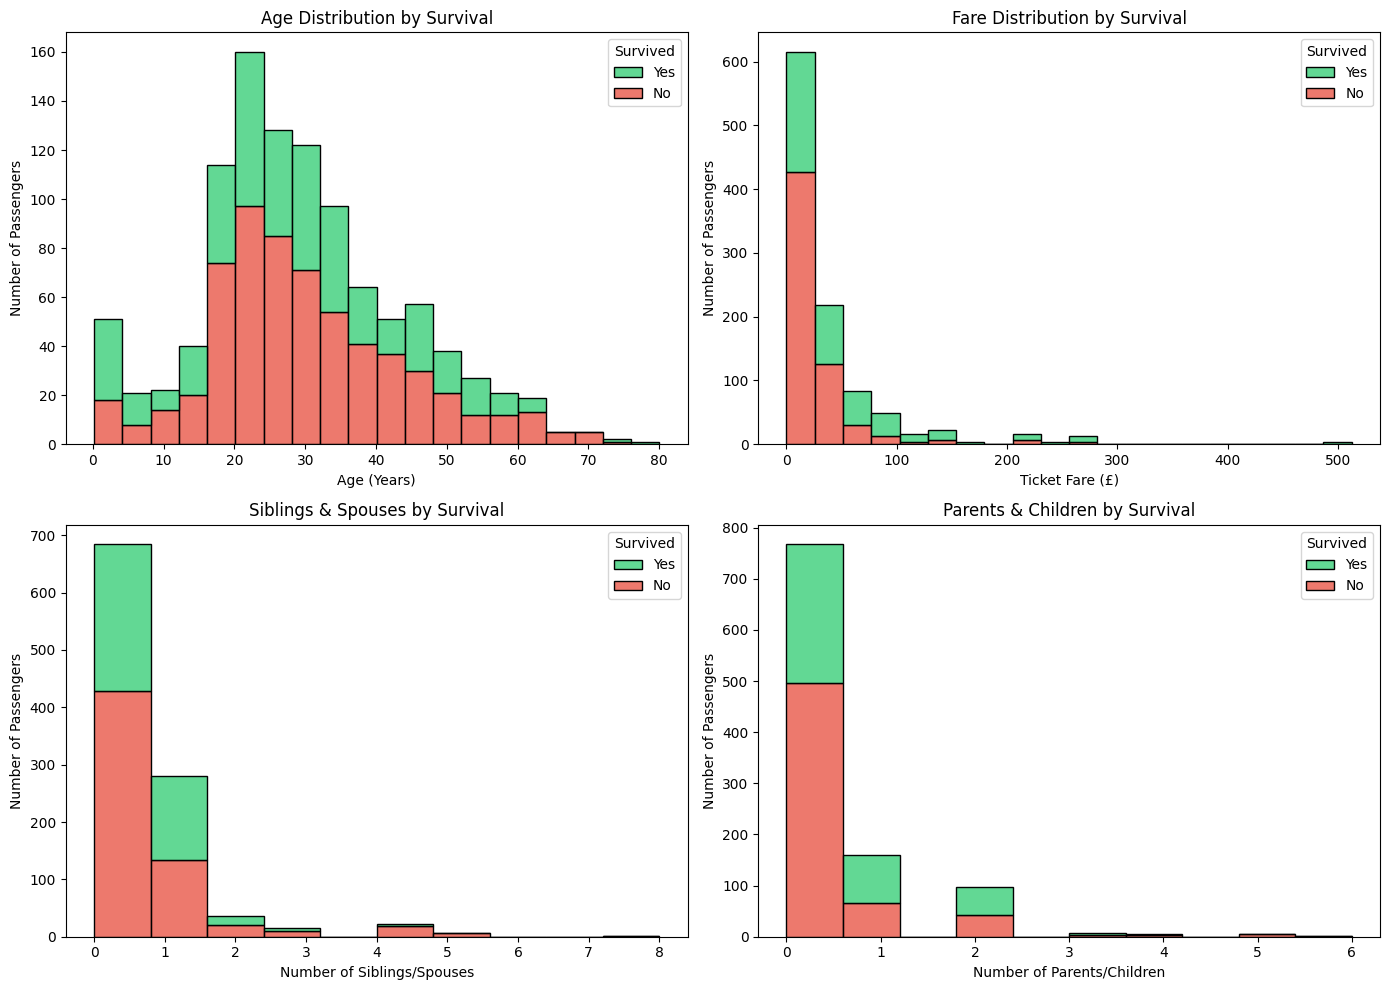

✓ Data explored


In [2]:
# 1. Look at the first 5 passengers
display(df.head())

# 2. Plot the distribution of our 4 starting features, separated by Survival
plt.figure(figsize=(14, 10))
palette = {'No': '#e74c3c', 'Yes': '#2ecc71'}

# Age
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='Age', hue='Survived', palette=palette, multiple='stack', bins=20)
plt.title('Age Distribution by Survival')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Passengers')

# Fare
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='Fare', hue='Survived', palette=palette, multiple='stack', bins=20)
plt.title('Fare Distribution by Survival')
plt.xlabel('Ticket Fare (£)')
plt.ylabel('Number of Passengers')

# Siblings/Spouses
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='Siblings_Spouses', hue='Survived', palette=palette, multiple='stack', bins=10)
plt.title('Siblings & Spouses by Survival')
plt.xlabel('Number of Siblings/Spouses')
plt.ylabel('Number of Passengers')

# Parents/Children
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Parents_Children', hue='Survived', palette=palette, multiple='stack', bins=10)
plt.title('Parents & Children by Survival')
plt.xlabel('Number of Parents/Children')
plt.ylabel('Number of Passengers')

plt.tight_layout()
plt.show()

print("✓ Data explored")

<div class="alert alert-info">

### 👀 Exploring the Raw Data

From the plots, we can see that unfortunately, more people died than survived. We also see the age distribution shows many young adults in their 20s and 30s.

Now look closely at the table's features:
- `Siblings_Spouses` and `Parents_Children` are completely separate numbers representing family members.
- `Age` ranges from 0 to 80.
- `Fare` has huge variance. Some tickets were £7, others were over £500!

Let's train a neural network on this completely **raw** dataset to get our starting baseline accuracy.

</div>

---

## <span style="color: purple;">Step 2 - Train a baseline model</span>

We'll use a Neural Network to predict survival using just these raw features as they are.

In [3]:
# Set our starting raw features and target
X_raw = df[['Age', 'Siblings_Spouses', 'Parents_Children', 'Fare']]
y_target = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_target, test_size=0.2, random_state=42)

# Train a fast Neural Network on the raw data
baseline_model = MLPClassifier(hidden_layer_sizes=(5), max_iter=200, random_state=42)
baseline_model.fit(X_train, y_train)

# Test it
predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, predictions)

print(f"✓ Baseline Accuracy on Raw Data: {baseline_accuracy * 100:.1f}%")

✓ Baseline Accuracy on Raw Data: 65.1%


<div class="alert alert-info">

Our baseline model gets around 65% accuracy. Neural Networks actually struggle quite a bit when data isn't scaled or engineered properly. Let's fix that!

</div>

---

## <span style="color: purple;">Step 3 - Feature Construction</span>

First, we will construct a new variable: **FamilySize**.

The model might struggle to link "Siblings" and "Parents" together to realize someone was part of a large family. We can help it capture the **"Social Context"**. A single number representing the whole family is a much stronger predictor of survival than two separate, smaller numbers.

<div class="alert alert-info">

**Feature Construction** - Creating `FamilySize` by adding `Siblings_Spouses` + `Parents_Children` + `1` (for the passenger themselves).

</div>

In [4]:
# Create the new FamilySize feature
df['FamilySize'] = df['Siblings_Spouses'] + df['Parents_Children'] + 1

display(df[['Siblings_Spouses', 'Parents_Children', 'FamilySize']].head())
print("✓ New variable created")

,Siblings_Spouses,Parents_Children,FamilySize
0,0,0,1
1,1,2,4
2,1,2,4
3,1,2,4
4,1,2,4


✓ New variable created


---

## <span style="color: purple;">Step 4 - Feature Transformation</span>

Next, let's look at `Fare`. Most people bought cheap tickets, but a few extremely wealthy people paid huge sums (over £500). 

We will apply a **Log Transform** to turn the Fare column from a heavily skewed distribution into something closer to a normal "Bell Curve".

<div class="alert alert-info">

**Handling Outliers** - Without this transformation, the few people who paid £500 would "confuse" the model's math, making it ignore the thousands of people who paid £10.

</div>

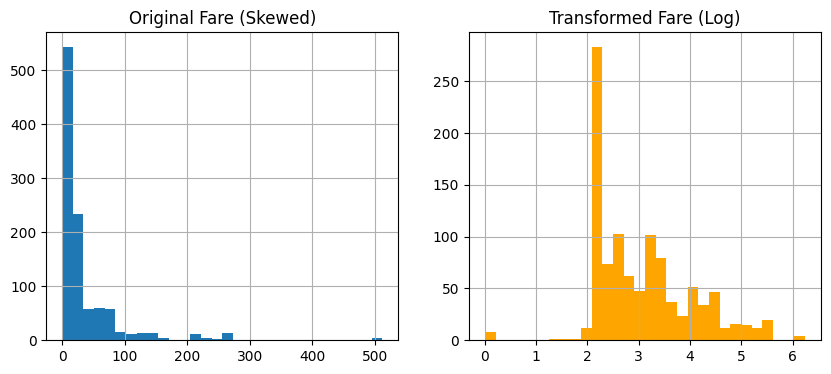

✓ Feature transformed


In [5]:
# Transform: squish the giant Fare numbers using a logarithm
df['Log_Fare'] = np.log1p(df['Fare'])

# Let's see the before & after visually
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Fare'].hist(bins=30)
plt.title("Original Fare (Skewed)")

plt.subplot(1, 2, 2)
df['Log_Fare'].hist(bins=30, color='orange')
plt.title("Transformed Fare (Log)")
plt.show()

print("✓ Feature transformed")

<div class="alert alert-info">

Notice how the original Fare graph (blue) is entirely squashed to the left because of a few £500 tickets. The orange graph (Log Fare) is much more balanced and evenly spread out. The model will understand this much better!

</div>

---

## <span style="color: purple;">Step 5 - Standardization (Scaling)</span>

Finally, we have `Age` (0-80) and `Log_Fare` (0-8). These scales are completely different!

A neural network might mistakenly think that Age is 10x more important than Log_Fare just because the numbers themselves are bigger. We fix this using **Standardisation**.

<div class="alert alert-success">

**Standardization** - Adjusting the scale of all numeric variables so they share the exact same range (a mean of 0 and a standard deviation of 1). This creates a "Level Playing Field" where each feature contributes to the neural network equally.

</div>

In [10]:
# Update our features to include out new, better columns
X_engineered = df[['Age', 'FamilySize', 'Log_Fare']]

# Split the new engineered data
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_engineered, y_target, test_size=0.2, random_state=42)

# Standardize (Scale) the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_eng) # scale training set
X_test_scaled = scaler.transform(X_test_eng)       # scale test set

print("✓ Data Standardised")

✓ Data Standardised


---

## <span style="color: purple;">Step 6 - Evaluate performance changes</span>

Let's retrain our exact same Neural Network, but this time we'll give it our newly crafted, transformed, and leveled-out features!

In [11]:
# Train the exact same type of Neural Network
engineered_model = MLPClassifier(hidden_layer_sizes=(5), max_iter=200, random_state=42)
engineered_model.fit(X_train_scaled, y_train_eng)

eng_predictions = engineered_model.predict(X_test_scaled)
engineered_accuracy = accuracy_score(y_test_eng, eng_predictions)

print(f"Old Accuracy (Raw Baseline): {baseline_accuracy * 100:.1f}%")
print(f"New Accuracy (Engineered):   {engineered_accuracy * 100:.1f}%")

if engineered_accuracy > baseline_accuracy:
    print(f"\n✓ Success! We boosted model performance simply by handing it better data!")
else:
    print("\nOops, our features didn't help!")

Old Accuracy (Raw Baseline): 65.1%
New Accuracy (Engineered):   68.9%

✓ Success! We boosted model performance simply by handing it better data!


<div class="alert alert-info">

**We improved the performance of the model by only using feature engineering!** This is immensely usefule because in real life extra is often difficult to come by and we don't always have the resources to train a fancy complex model.

</div>

---

## <span style="color: purple;">🧠 What did we just do?</span>

We noticed that our raw data was messy and on difficult scales for a Neural Network to automatically understand. We utilised three feature enginering techniques (there are plenty more).

1. **Construction**: By combining separate family columns, we captured the social context mathematically.
2. **Transformation**: By logging the fare, we prevented super-wealthy outliers from destroying the model's math.
3. **Standardization**: By scaling everything to the same playing field, we ensured no feature dominated another just due to sheer number size.

Most importantly, our model's accuracy improved significantly **without changing the model itself**. Sometimes giving a model "better" data is more valuable than using a complex model that is difficult to train!

### Summary

| Word | What it means |
|------|--------------|
| **Feature Engineering** | Creating new features or transforming existing ones to explicitly give a model "better" information |
| **Feature Construction** | Combining multiple variables into a single, stronger predictor |
| **Feature Transformation** | Applying math functions (like Log) to change a column's distribution |
| **Standardization** | Adjusting limits to level out numeric variables down to an equal scale |


---

## <span style="color: purple;">🧪 Quick Quiz</span>

Test yourself on what you just learned. Run the code cell, select your answer for each question, then click **Check answers**.


In [9]:
from quiz import run_b11_quiz
run_b11_quiz()